In [1]:
import os, json, shutil
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd


SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")
META_PATH = SPLITS_DIR / "splits_metadata.json"

NNUNET_BASE = Path(r"D:\master_experiments\models_configs\nnUNet")
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"
NNUNET_PREP = NNUNET_BASE / "nnUNet_preprocessed"
NNUNET_RES = NNUNET_BASE / "nnUNet_results"

for p in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)
os.environ["nnUNet_results"] = str(NNUNET_RES)

DATASET_ID = 902
DATASET_NAME = "BraTS2020_Baseline_4ch"
DATASET_FOLDER = NNUNET_RAW / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

for p in [imagesTr, labelsTr, imagesTs]:
    p.mkdir(parents=True, exist_ok=True)

SPLITS_DIR.exists(), META_PATH.exists(), DATASET_FOLDER

(True,
 True,
 WindowsPath('D:/master_experiments/models_configs/nnUNet/nnUNet_raw/Dataset902_BraTS2020_Baseline_4ch'))

In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids = meta["ids"]["val"]
test_ids = meta["ids"]["test"]

train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("Counts:", len(train_ids), len(val_ids), len(test_ids))
print("OK: sem repetição entre splits")

Counts: 245 52 53
OK: sem repetição entre splits


In [3]:
MODS = ["flair", "t1", "t1ce", "t2"]
FILE_ENDING = ".nii.gz"

def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def save_as_niigz(src_path: Path, dst_path: Path):
    if src_path.name.lower().endswith(".nii.gz"):
        shutil.copy2(src_path, dst_path)
        return
    img = nib.load(str(src_path))
    nib.save(img, str(dst_path))

def save_label_remap_niigz(seg_path: Path, dst_path: Path):
    img = nib.load(str(seg_path))
    data = np.asanyarray(img.dataobj).astype(np.int16)
    data[data == 4] = 3
    out = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(out, str(dst_path))

def check_case(split_name: str, case_id: str):
    d = case_dir(split_name, case_id)
    assert d.exists(), f"Missing folder: {d}"
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
    return True

for cid in train_ids[:3]:
    check_case("train", cid)
print("OK")

OK


In [4]:
def export_case_to_nnunet(split_name: str, case_id: str, to_images: Path, to_labels: Path | None):
    d = case_dir(split_name, case_id)
    for ch, mod in enumerate(MODS):
        src = find_file(d, mod)
        dst = to_images / f"{case_id}_{ch:04d}{FILE_ENDING}"
        save_as_niigz(src, dst)
    if to_labels is not None:
        seg = find_file(d, "seg")
        dst = to_labels / f"{case_id}{FILE_ENDING}"
        save_label_remap_niigz(seg, dst)

for cid in tqdm(train_ids, desc="Export train -> imagesTr/labelsTr"):
    export_case_to_nnunet("train", cid, imagesTr, labelsTr)

for cid in tqdm(val_ids, desc="Export val -> imagesTr/labelsTr"):
    export_case_to_nnunet("val", cid, imagesTr, labelsTr)

for cid in tqdm(test_ids, desc="Export test -> imagesTs"):
    export_case_to_nnunet("test", cid, imagesTs, None)

len(list(imagesTr.glob(f"*{FILE_ENDING}"))), len(list(labelsTr.glob(f"*{FILE_ENDING}"))), len(list(imagesTs.glob(f"*{FILE_ENDING}")))

Export test -> imagesTs: 100%|██████████| 53/53 [00:20<00:00,  2.53it/s]


(1188, 297, 212)

In [5]:
dataset_json = {
    "channel_names": {"0": "FLAIR", "1": "T1", "2": "T1ce", "3": "T2"},
    "labels": {"background": 0, "non_enhancing_and_necrosis": 1, "edema": 2, "enhancing_tumor": 3},
    "numTraining": len(list(labelsTr.glob(f"*{FILE_ENDING}"))),
    "file_ending": FILE_ENDING
}

with open(DATASET_FOLDER / "dataset.json", "w", encoding="utf-8") as f:
    json.dump(dataset_json, f, indent=2, ensure_ascii=False)

DATASET_FOLDER / "dataset.json"

WindowsPath('D:/master_experiments/models_configs/nnUNet/nnUNet_raw/Dataset902_BraTS2020_Baseline_4ch/dataset.json')

In [6]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity -c 3d_fullres -np 4

Fingerprint extraction...
Dataset902_BraTS2020_Baseline_4ch
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [139. 170. 138.], 3d_lowres: [139, 170, 138]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 105, 'patch_size': (np.int64(192), np.int64(160)


100%|##########| 297/297 [00:36<00:00,  8.21it/s]

100%|##########| 297/297 [05:09<00:00,  1.04s/it]


In [7]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
preprocessed_dataset.exists()

True

In [8]:
splits_final = [{"train": sorted(train_ids), "val": sorted(val_ids)}]
with open(preprocessed_dataset / "splits_final.json", "w", encoding="utf-8") as f:
    json.dump(splits_final, f, indent=2, ensure_ascii=False)

preprocessed_dataset / "splits_final.json"

WindowsPath('D:/master_experiments/models_configs/nnUNet/nnUNet_preprocessed/Dataset902_BraTS2020_Baseline_4ch/splits_final.json')

In [9]:
prep = Path(os.environ["nnUNet_preprocessed"]) / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
print("Preprocessed dir:", prep)

plans = list(prep.glob("nnUNetPlans*.json"))
print("Plans files:", plans)

if plans:
    with open(plans[0], "r", encoding="utf-8") as f:
        plans_json = json.load(f)
    print("Top keys:", plans_json.keys())

Preprocessed dir: D:\master_experiments\models_configs\nnUNet\nnUNet_preprocessed\Dataset902_BraTS2020_Baseline_4ch
Plans files: [WindowsPath('D:/master_experiments/models_configs/nnUNet/nnUNet_preprocessed/Dataset902_BraTS2020_Baseline_4ch/nnUNetPlans.json')]
Top keys: dict_keys(['dataset_name', 'plans_name', 'original_median_spacing_after_transp', 'original_median_shape_after_transp', 'image_reader_writer', 'transpose_forward', 'transpose_backward', 'configurations', 'experiment_planner_used', 'label_manager', 'foreground_intensity_properties_per_channel'])


In [10]:
!nnUNetv2_train {DATASET_ID} 3d_fullres 0 -device cuda -tr nnUNetTrainer_100epochs


############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-04-26 04:04:24.331470: do_dummy_2d_data_aug: False
2026-04-26 04:04:24.332471: Using splits from existing split file: D:\master_experiments\models_configs\nnUNet\nnUNet_preprocessed\Dataset902_BraTS2020_Baseline_4ch\splits_final.json
2026-04-26 04:04:24.333471: The split file contains 1 spl

In [11]:
pattern = str(NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / "*" / "fold_0" / "validation" / "summary.json")
cands = glob(pattern)
cands[:2], len(cands)

(['D:\\master_experiments\\models_configs\\nnUNet\\nnUNet_results\\Dataset902_BraTS2020_Baseline_4ch\\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\\fold_0\\validation\\summary.json'],
 1)

In [12]:
if cands:
    with open(cands[0], "r", encoding="utf-8") as f:
        summary = json.load(f)
    list(summary.keys())

In [13]:
PRED_TEST_OUT = Path(r"D:\nnUNet_preds\brats2020_test_pred")
PRED_TEST_OUT.mkdir(parents=True, exist_ok=True)

!nnUNetv2_predict -i "{imagesTs}" -o "{PRED_TEST_OUT}" -d {DATASET_ID} -c 3d_fullres -f 0 -tr nnUNetTrainer_100epochs


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 53 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 53 cases that I would like to predict

Predicting BraTS20_Training_006:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS20_Training_006

Predicting BraTS20_Training_008:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS20_Training_008

Predicting BraTS20_Training_014:
perform_everything_on_device: True
sending off prediction t


100%|##########| 8/8 [00:03<00:00,  2.44it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 8/8 [00:02<00:00,  3.45it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 8/8 [00:02<00:00,  3.43it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 4/4 [00:01<00:00,  3.65it/s]

100%|##########| 4/4 [00:01<00:00,  3.64it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 4/4 [00:01<00:00,  3.65it/s]

100%|##########| 4/4 [00:01<00:00,  3.63it/s]

100%|##########| 8/8 [00:02<00:00,  3.43it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 8/8 [00:02<00:00,  3.45it/s]

100%|##########| 8/8 [00:02<00:00,  3.44it/s]

100%|##########| 4/4 [00:01<00:00,  3.62it/s]

100%|##########| 8/8 [00:02<00:00,  3.45it/s]

100%|##########| 8/8 [00:02<00:00,  3.43it/s]

100%|##########| 8/8 [00:02<00:00,  3.43it/s]

100%|##########| 4/4 [00:01<00:00,  3.65it/s]

100%|#######

In [14]:
def load_arr(p: Path):
    return np.asanyarray(nib.load(str(p)).dataobj)

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def get_pred_path(cid: str):
    p = PRED_TEST_OUT / f"{cid}.nii.gz"
    if p.exists():
        return p
    p = PRED_TEST_OUT / f"{cid}.nii"
    if p.exists():
        return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

rows = []
for cid in tqdm(test_ids, desc="Dice por caso"):
    gt_path = find_file(case_dir("test", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    gt[gt == 4] = 3  # BraTS2020: remap 4->3
    pr = load_arr(pr_path).astype(np.int16)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)

    wt = dice((gt > 0), (pr > 0))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))
    et = dice((gt == 3), (pr == 3))

    rows.append({
        "id": cid,
        "dice_c1": d1,
        "dice_c2": d2,
        "dice_c3": d3,
        "dice_WT": wt,
        "dice_TC": tc,
        "dice_ET": et,
    })

df = pd.DataFrame(rows)
df.describe()

Dice por caso: 100%|██████████| 53/53 [00:05<00:00,  9.57it/s]


,dice_c1,dice_c2,dice_c3,dice_WT,dice_TC,dice_ET
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.740838,0.830152,0.835378,0.907191,0.910314,0.835378
std,0.225966,0.111826,0.164662,0.073189,0.080637,0.164662
min,0.067144,0.516106,0.017595,0.660699,0.583327,0.017595
25%,0.629340,0.777172,0.822022,0.899976,0.889603,0.822022
50%,0.813176,0.868552,0.892866,0.934755,0.936975,0.892866
75%,0.901753,0.909545,0.924576,0.957796,0.961185,0.924576
max,0.987187,0.962566,0.967739,0.970147,0.982337,0.967739



Paciente: BraTS20_Training_156 | split=test | z=69
Dice C1 (necrose/non-enh): 0.8680
Dice C2 (edema):          0.9472
Dice C3 (enhancing):      0.9552
Dice WT (gt>0):           0.9601
Dice TC (1|3):            0.9443
Dice ET (3):              0.9552



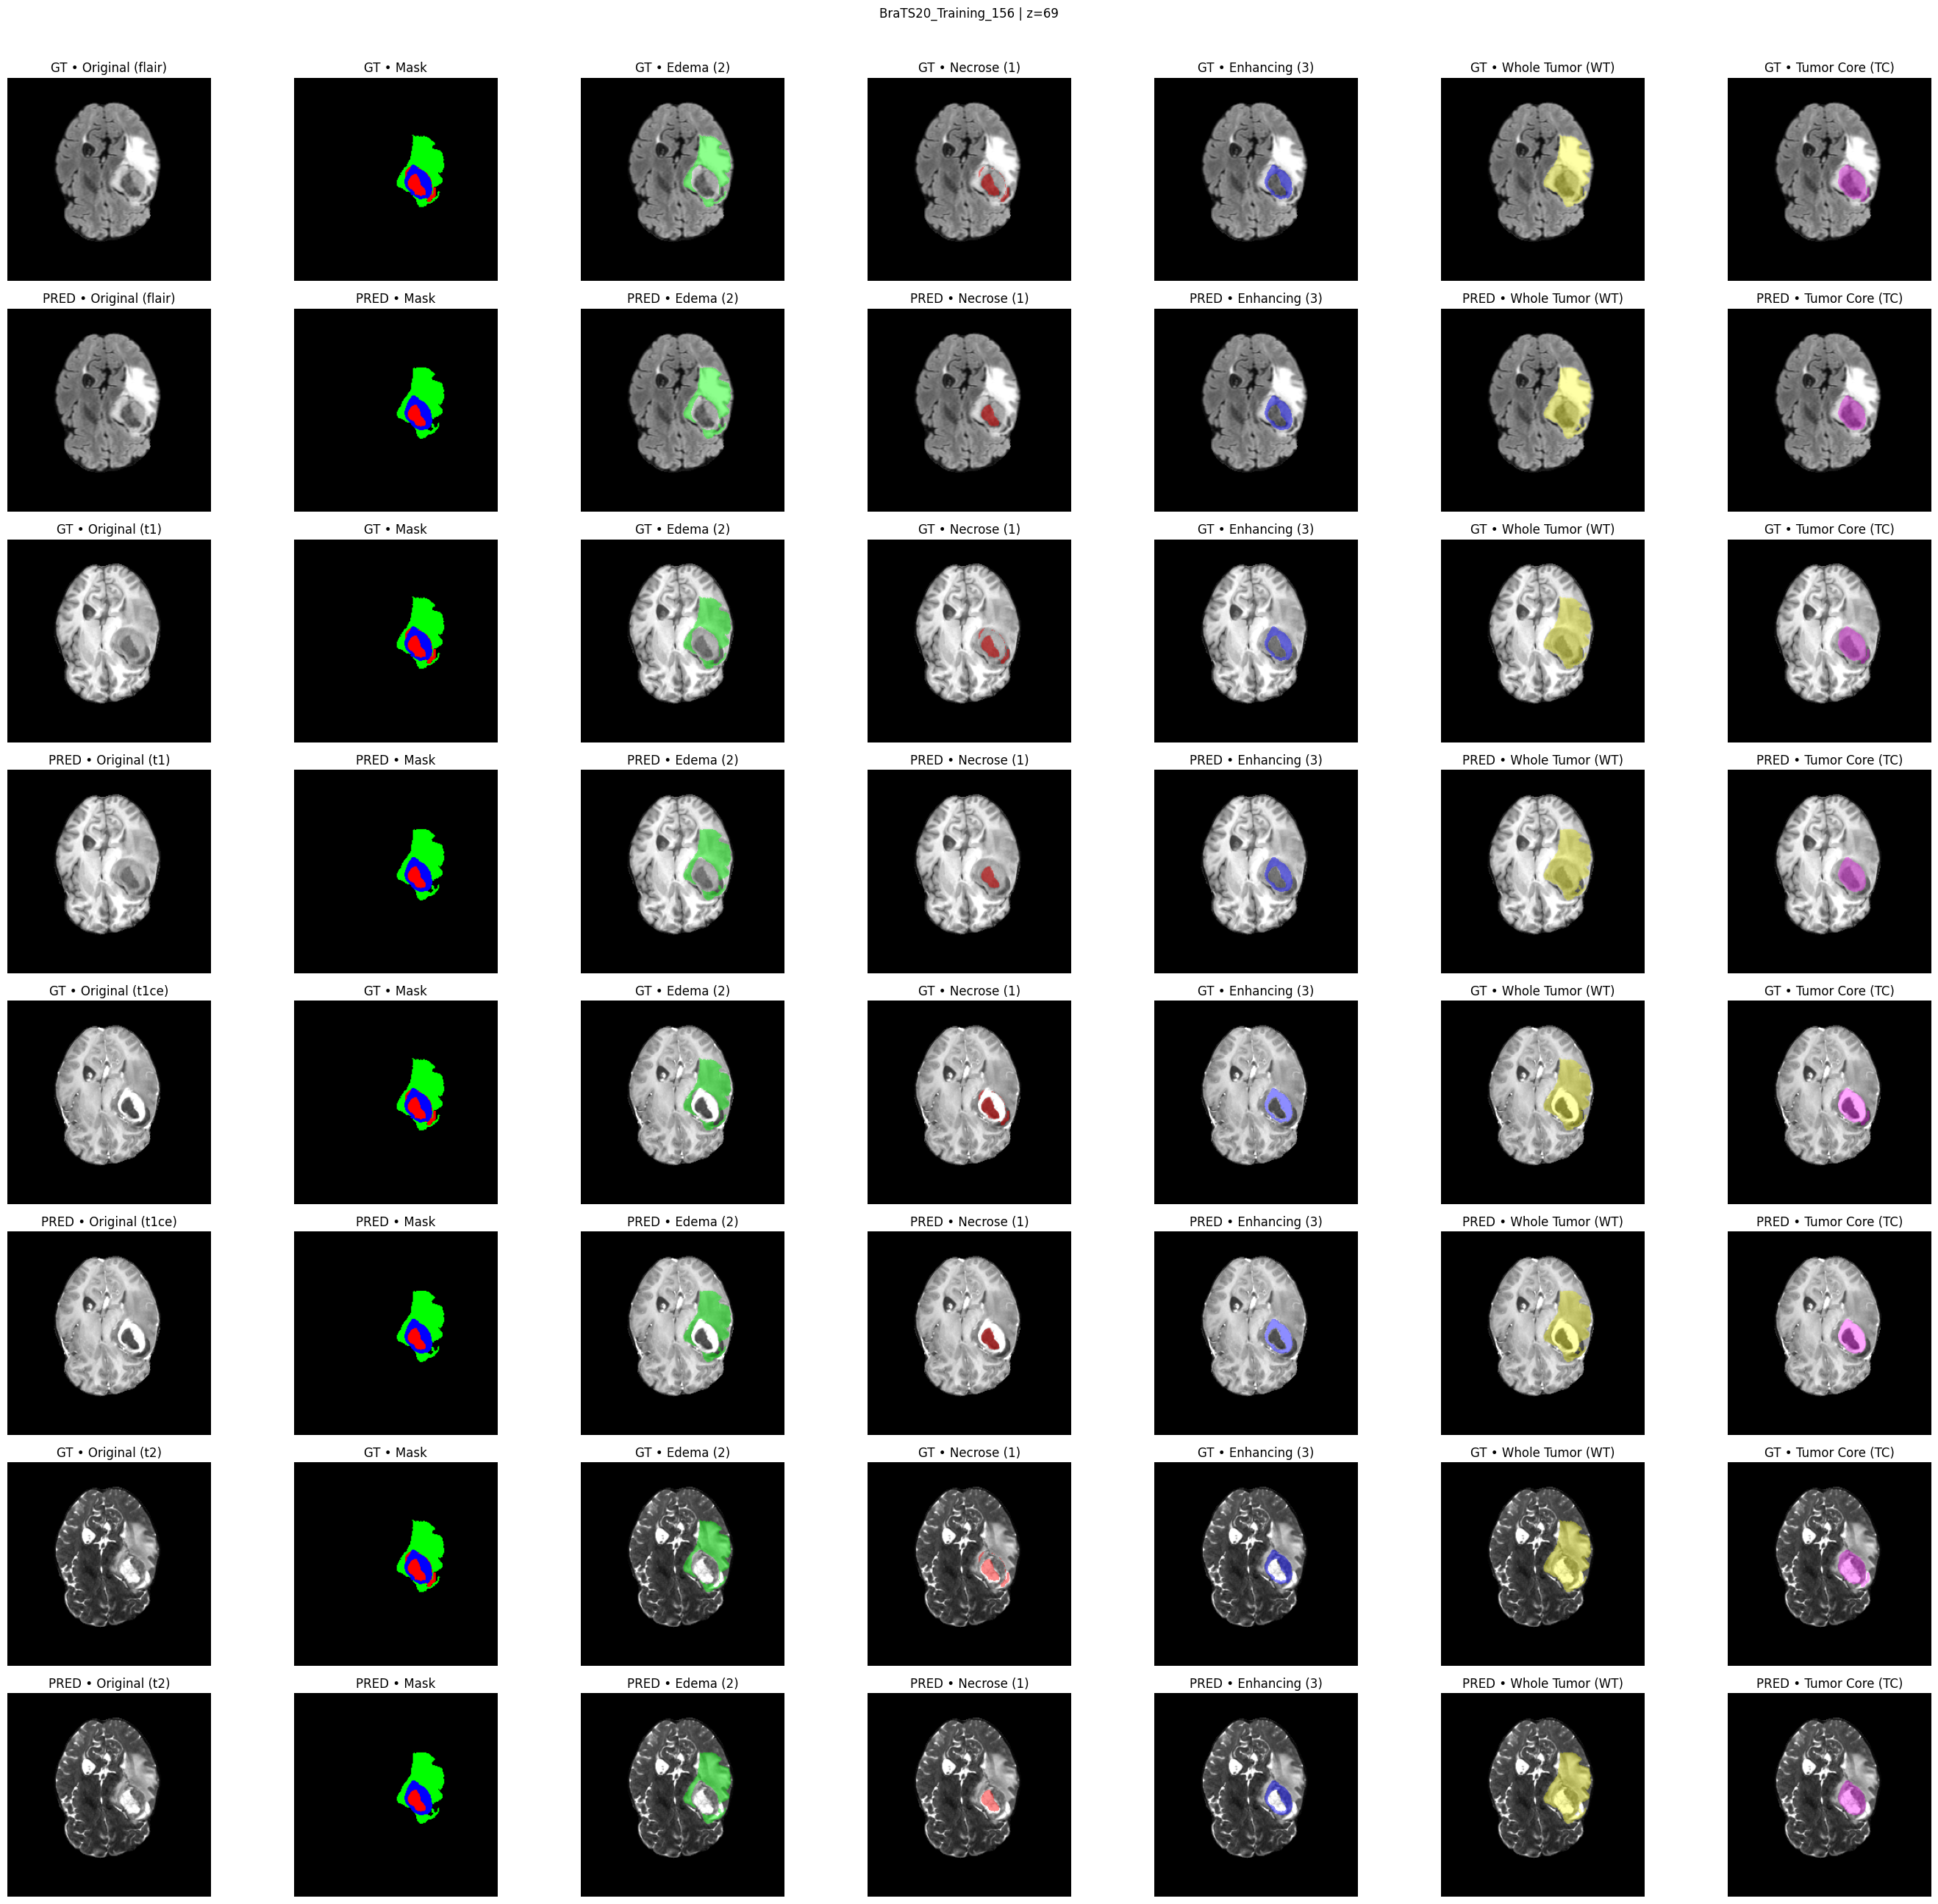

In [15]:
def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((mask2d.shape[0], mask2d.shape[1], 4), dtype=np.float32)
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color_rgb
    rgba[..., 3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title)
    ax.axis("off")

def load_arr(p):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return np.squeeze(arr)  # remove all size-1 dimensions

def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(gt):
    counts = (gt > 0).sum(axis=(0, 1))
    return int(counts.argmax())

cmap_mask = ListedColormap([
    (0, 0, 0, 1),
    (1, 0, 0, 1),
    (0, 1, 0, 1),
    (0, 0, 1, 1),
])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4], cmap_mask.N)

def masks_from_seg(seg):
    nec = (seg == 1)
    ede = (seg == 2)
    enh = (seg == 3)
    wt  = (seg > 0)
    tc  = (seg == 1) | (seg == 3)
    et  = (seg == 3)
    return nec, ede, enh, wt, tc, et

def plot_random_case_multimodal_gt_pred(
    ids_list,
    split_name="test",
    seed=None,
    z=None,
    alpha_cls=0.45,
    alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))

    d = case_dir(split_name, cid)

    gt_path = find_file(d, "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    gt[gt == 4] = 3
    pr[pr == 4] = 3

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(gt > 0, pr > 0)
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))
    et = dice(gt == 3, pr == 3)

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose/non-enh): {d1:.4f}")
    print(f"Dice C2 (edema):          {d2:.4f}")
    print(f"Dice C3 (enhancing):      {d3:.4f}")
    print(f"Dice WT (gt>0):           {wt:.4f}")
    print(f"Dice TC (1|3):            {tc:.4f}")
    print(f"Dice ET (3):              {et:.4f}\n")

    gt2d = gt[:, :, z].T
    pr2d = pr[:, :, z].T

    gt_nec, gt_ede, gt_enh, gt_wt, gt_tc, _ = masks_from_seg(gt2d)
    pr_nec, pr_ede, pr_enh, pr_wt, pr_tc, _ = masks_from_seg(pr2d)

    n_mods = len(MODS)
    nrows = 2 * n_mods
    ncols = 7

    fig, axes = plt.subplots(nrows, ncols, figsize=(28, 3.2 * nrows))
    fig.suptitle(f"{cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img_path = find_file(d, mod)
        img = load_arr(img_path)
        img2d = norm01(img[:, :, z]).T

        r_gt = 2 * i
        r_pr = 2 * i + 1

        axes[r_gt, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt, 0].set_title(f"GT • Original ({mod})")
        axes[r_gt, 0].axis("off")

        axes[r_gt, 1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt, 1].set_title("GT • Mask")
        axes[r_gt, 1].axis("off")

        overlay(axes[r_gt, 2], img2d, gt_ede, (0, 1, 0), alpha=alpha_cls,  title="GT • Edema (2)")
        overlay(axes[r_gt, 3], img2d, gt_nec, (1, 0, 0), alpha=alpha_cls,  title="GT • Necrose (1)")
        overlay(axes[r_gt, 4], img2d, gt_enh, (0, 0, 1), alpha=alpha_cls,  title="GT • Enhancing (3)")
        overlay(axes[r_gt, 5], img2d, gt_wt,  (1, 1, 0), alpha=alpha_comp, title="GT • Whole Tumor (WT)")
        overlay(axes[r_gt, 6], img2d, gt_tc,  (1, 0, 1), alpha=alpha_comp, title="GT • Tumor Core (TC)")

        axes[r_pr, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr, 0].set_title(f"PRED • Original ({mod})")
        axes[r_pr, 0].axis("off")

        axes[r_pr, 1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr, 1].set_title("PRED • Mask")
        axes[r_pr, 1].axis("off")

        overlay(axes[r_pr, 2], img2d, pr_ede, (0, 1, 0), alpha=alpha_cls,  title="PRED • Edema (2)")
        overlay(axes[r_pr, 3], img2d, pr_nec, (1, 0, 0), alpha=alpha_cls,  title="PRED • Necrose (1)")
        overlay(axes[r_pr, 4], img2d, pr_enh, (0, 0, 1), alpha=alpha_cls,  title="PRED • Enhancing (3)")
        overlay(axes[r_pr, 5], img2d, pr_wt,  (1, 1, 0), alpha=alpha_comp, title="PRED • Whole Tumor (WT)")
        overlay(axes[r_pr, 6], img2d, pr_tc,  (1, 0, 1), alpha=alpha_comp, title="PRED • Tumor Core (TC)")

    plt.tight_layout()
    plt.show()

    return cid, z, {"dice_c1": d1, "dice_c2": d2, "dice_c3": d3, "dice_WT": wt, "dice_TC": tc, "dice_ET": et}

cid, z, dice_dict = plot_random_case_multimodal_gt_pred(test_ids, split_name="test", seed=None)